<a href="https://colab.research.google.com/github/harshadbabar26-dev/HB1/blob/main/UAEpolicy__analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UAE

multiple linear regression for emigration policy method no 2


In [ ]:
# ==========================
# STEP 1: Apply PCA to Economic Variables
# ==========================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# Select only UAE data
df = df[df["Country"] == "United Arab Emirates"]

# -------------------------
# Policy Variable (DO NOT APPLY PCA)
# -------------------------
policy = df["Emiratisation_Policy"]

# -------------------------
# Target Variable
# -------------------------
y = df["Migration"]

# -------------------------
# Economic Variables (Apply PCA here)
# -------------------------
economic = df[[
    "Population",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"
]]

# -------------------------
# Standardize Economic Variables
# -------------------------
scaler = StandardScaler()

economic_scaled = scaler.fit_transform(economic)

# -------------------------
# Apply PCA
# Keep enough components to explain 95% of the variance
# -------------------------
pca = PCA(n_components=0.95)

economic_pca = pca.fit_transform(economic_scaled)

print("Original Variables :", economic.shape[1])
print("Principal Components :", economic_pca.shape[1])

print("\nExplained Variance Ratio")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance")
print(sum(pca.explained_variance_ratio_))

Original Variables : 5
Principal Components : 5

Explained Variance Ratio
[0.54509498 0.23299984 0.11065411 0.06071758 0.05053349]

Total Explained Variance
1.0


In [ ]:
# ==========================
# STEP 2: Regression Using Policy + PCA Components
# ==========================

import statsmodels.api as sm
import pandas as pd

# Convert PCA output to DataFrame
pca_df = pd.DataFrame(
    economic_pca,
    columns=[f"PC{i+1}" for i in range(economic_pca.shape[1])]
)

# Combine Policy Variable with PCA Components
X = pd.concat(
    [
        policy.reset_index(drop=True),
        pca_df
    ],
    axis=1
)

# Add Constant
X = sm.add_constant(X)

# Fit Multiple Linear Regression
model = sm.OLS(y.reset_index(drop=True), X).fit()

# Print Summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     1436.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.73e-35
Time:                        16:04:47   Log-Likelihood:                -458.94
No. Observations:                  37   AIC:                             931.9
Df Residuals:                      30   BIC:                             943.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.832e+06 

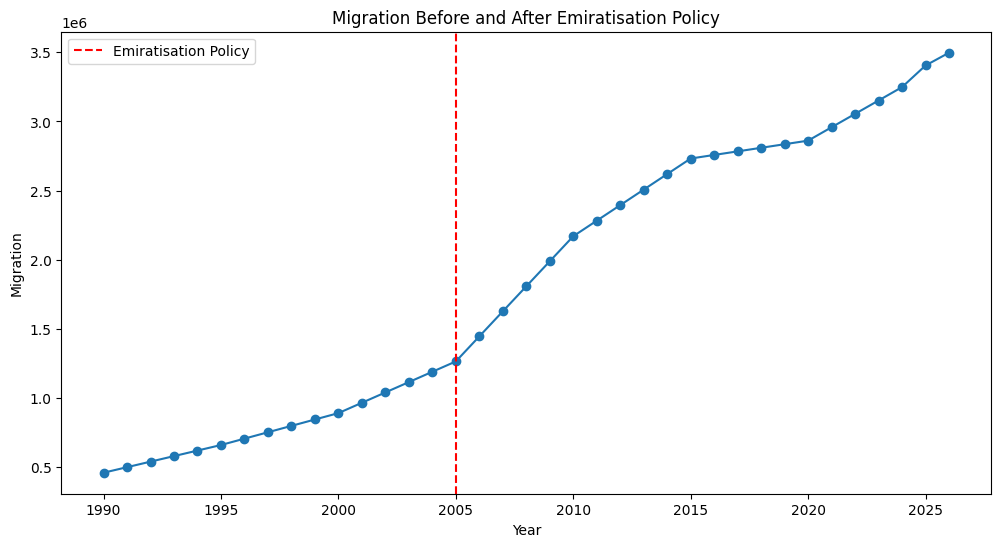

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["Year"], df["Migration"], marker='o')

plt.axvline(2005,
            color='red',
            linestyle='--',
            label='Emiratisation Policy')

plt.xlabel("Year")
plt.ylabel("Migration")

plt.title("Migration Before and After Emiratisation Policy")

plt.legend()

plt.show()

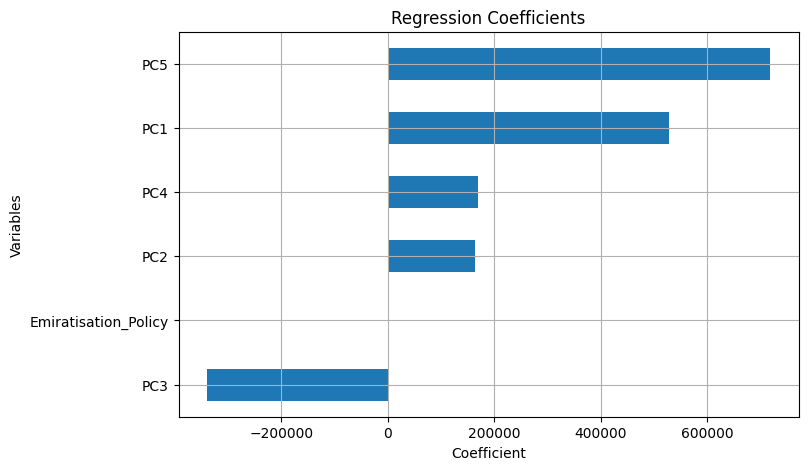

In [ ]:
import matplotlib.pyplot as plt

coef = model.params.drop("const")

plt.figure(figsize=(8,5))
coef.sort_values().plot(kind="barh")

plt.title("Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Variables")
plt.grid(True)

plt.show()


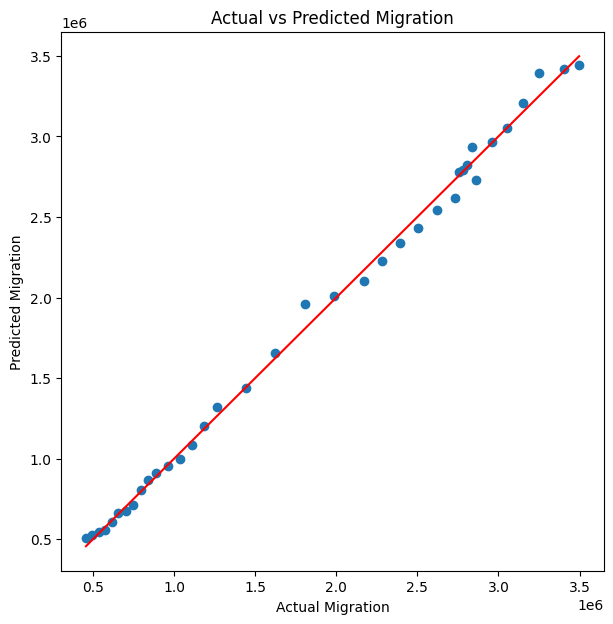

In [ ]:
import matplotlib.pyplot as plt

pred = model.predict(X)

plt.figure(figsize=(7,7))

plt.scatter(y, pred)

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')

plt.xlabel("Actual Migration")
plt.ylabel("Predicted Migration")
plt.title("Actual vs Predicted Migration")

plt.show()

descriptive analysis method 2

In [ ]:
# ==========================================
# Average Migration Before & After Emiratisation Policy
# ==========================================

# Before Policy (Before 2005)
before = df[df["Year"] < 2005]["Migration"]

# After Policy (2005 onwards)
after = df[df["Year"] >= 2005]["Migration"]

# Calculate Mean
before_avg = before.mean()
after_avg = after.mean()

print("Average Migration Before Policy :", round(before_avg,2))
print("Average Migration After Policy  :", round(after_avg,2))
print("Difference :", round(after_avg-before_avg,2))

Average Migration Before Policy : 774952.87
Average Migration After Policy  : 2554023.32
Difference : 1779070.45


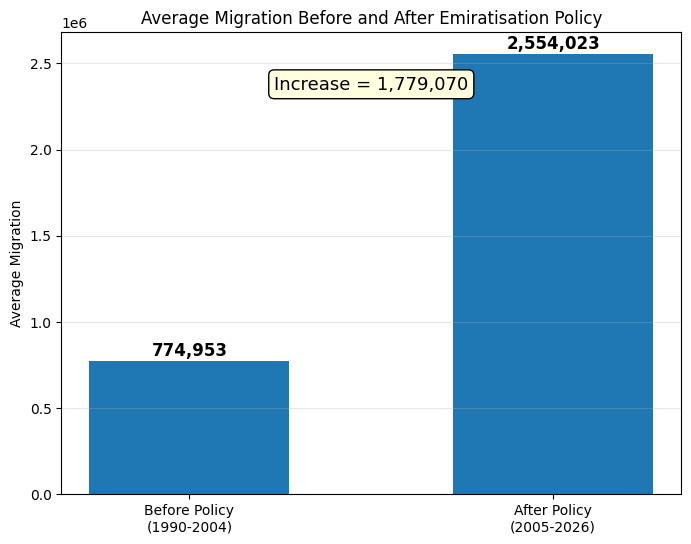

In [ ]:
import matplotlib.pyplot as plt

# Values
labels = ["Before Policy\n(1990-2004)",
          "After Policy\n(2005-2026)"]

values = [before_avg, after_avg]

plt.figure(figsize=(8,6))

bars = plt.bar(labels,
               values,
               width=0.55)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+30000,
        f"{bar.get_height():,.0f}",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.ylabel("Average Migration")

plt.title("Average Migration Before and After Emiratisation Policy")

# Difference annotation
plt.text(
    0.5,
    max(values)*0.92,
    f"Increase = {after_avg-before_avg:,.0f}",
    ha='center',
    fontsize=13,
    bbox=dict(boxstyle="round", facecolor="lightyellow")
)

plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
increase = ((after_avg-before_avg)/before_avg)*100

print(f"Percentage Increase = {increase:.2f}%")

Percentage Increase = 229.57%


Golden visa policy

In [ ]:
# ==========================================
# STEP 1: PCA on Economic Variables
# ==========================================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# Filter UAE
df = df[df["Country"] == "United Arab Emirates"]

# -------------------------
# Policy Variable
# -------------------------
policy = df["Golden_Visa"]

# -------------------------
# Target Variable
# -------------------------
y = df["Migration"]

# -------------------------
# Economic Variables
# -------------------------
economic = df[[
    "Population",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"
]]

# Standardize Economic Variables
scaler = StandardScaler()
economic_scaled = scaler.fit_transform(economic)

# PCA
pca = PCA(n_components=0.95)

economic_pca = pca.fit_transform(economic_scaled)

print("Original Variables :", economic.shape[1])
print("Principal Components :", economic_pca.shape[1])

print("\nExplained Variance Ratio")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance")
print(sum(pca.explained_variance_ratio_))

Original Variables : 5
Principal Components : 5

Explained Variance Ratio
[0.54509498 0.23299984 0.11065411 0.06071758 0.05053349]

Total Explained Variance
1.0


In [ ]:

# ==========================================
# STEP 2: Regression
# ==========================================

import statsmodels.api as sm

# Convert PCA output into DataFrame
pca_df = pd.DataFrame(
    economic_pca,
    columns=[f"PC{i+1}" for i in range(economic_pca.shape[1])]
)

# Combine Policy Variable + PCA Components
X = pd.concat(
    [
        policy.reset_index(drop=True),
        pca_df
    ],
    axis=1
)

# Add Constant
X = sm.add_constant(X)

# Fit Model
model = sm.OLS(
    y.reset_index(drop=True),
    X
).fit()

# Print Results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     1575.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           4.32e-36
Time:                        16:05:56   Log-Likelihood:                -457.23
No. Observations:                  37   AIC:                             928.5
Df Residuals:                      30   BIC:                             939.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.851e+06   1.48e+04    124.914      

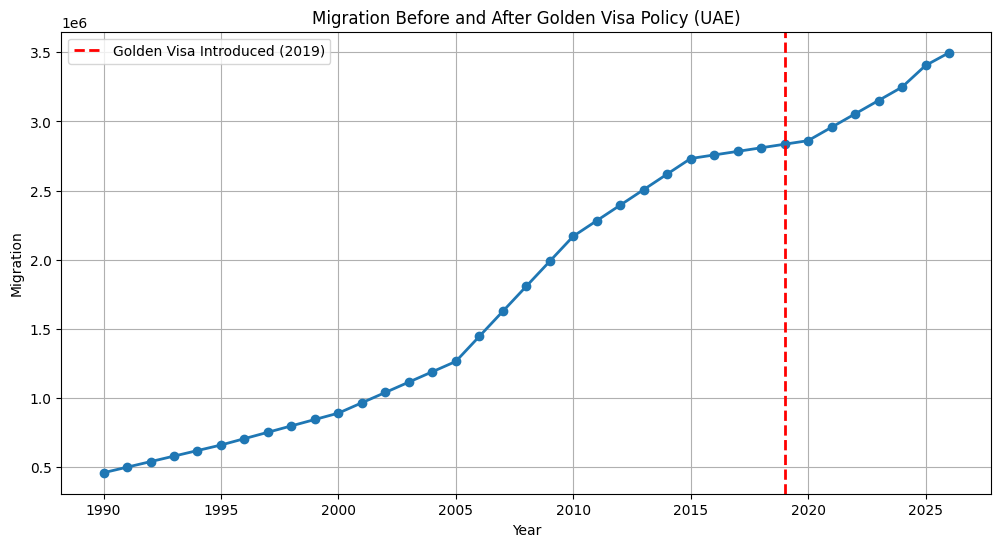

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["Year"], df["Migration"],
         marker='o',
         linewidth=2)

plt.axvline(
    x=2019,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Golden Visa Introduced (2019)'
)

plt.xlabel("Year")
plt.ylabel("Migration")
plt.title("Migration Before and After Golden Visa Policy (UAE)")
plt.legend()
plt.grid(True)

plt.show()

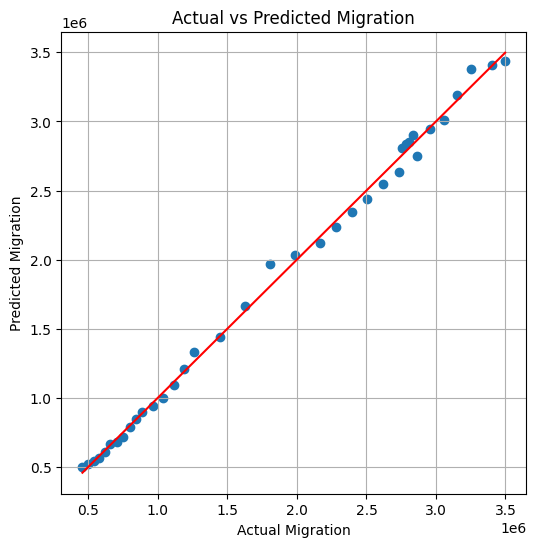

In [ ]:

import matplotlib.pyplot as plt

pred = model.predict(X)

plt.figure(figsize=(6,6))

plt.scatter(y, pred)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color='red'
)

plt.xlabel("Actual Migration")
plt.ylabel("Predicted Migration")

plt.title("Actual vs Predicted Migration")

plt.grid(True)

plt.show()


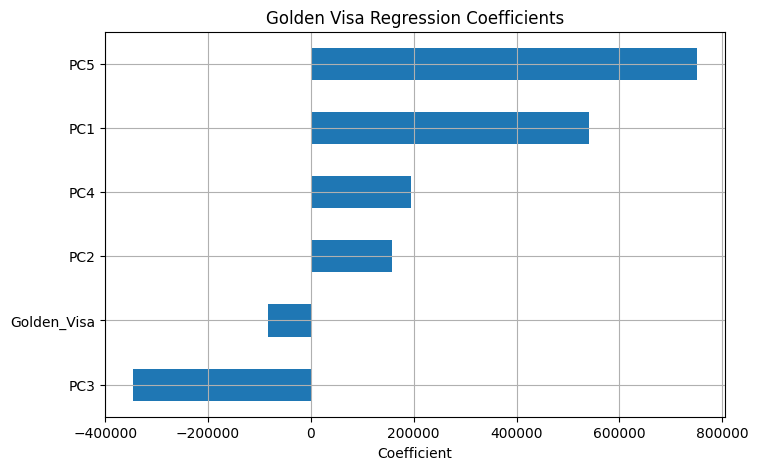

In [ ]:
import matplotlib.pyplot as plt

coef = model.params.drop("const")

plt.figure(figsize=(8,5))

coef.sort_values().plot(
    kind='barh'
)

plt.title("Golden Visa Regression Coefficients")
plt.xlabel("Coefficient")
plt.grid(True)

plt.show()


descriptive analysis method 2

In [ ]:
# ==========================================
# Average Migration Before & After Golden Visa
# Before = 3 years (2016-2018)
# After = 2019 onwards
# ==========================================

# Before Golden Visa (3 years)
before = df[(df["Year"] >= 2016) & (df["Year"] <= 2018)]["Migration"]

# After Golden Visa
after = df[df["Year"] >= 2019]["Migration"]

# Calculate averages
before_avg = before.mean()
after_avg = after.mean()

# Difference
difference = after_avg - before_avg

# Percentage increase
percentage = (difference / before_avg) * 100

print(f"Average Migration Before Golden Visa (2016-2018): {before_avg:,.0f}")
print(f"Average Migration After Golden Visa (2019 onwards): {after_avg:,.0f}")
print(f"Difference: {difference:,.0f}")
print(f"Percentage Change: {percentage:.2f}%")

Average Migration Before Golden Visa (2016-2018): 2,783,368
Average Migration After Golden Visa (2019 onwards): 3,126,476
Difference: 343,108
Percentage Change: 12.33%


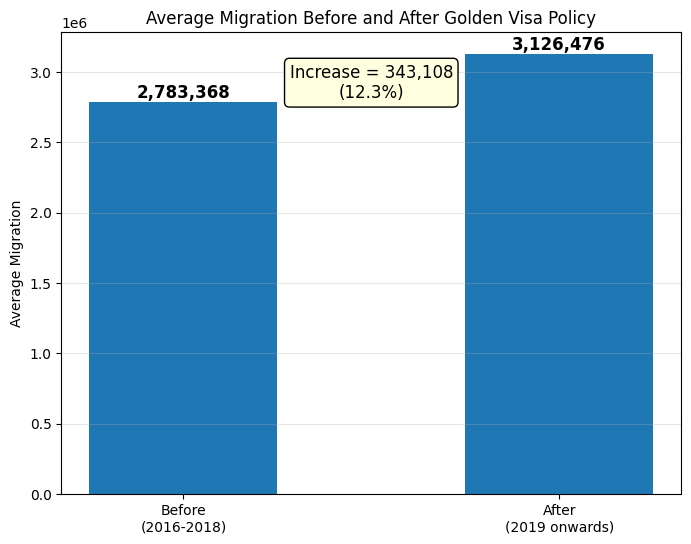

In [ ]:
import matplotlib.pyplot as plt

labels = [
    "Before\n(2016-2018)",
    "After\n(2019 onwards)"
]

values = [before_avg, after_avg]

plt.figure(figsize=(8,6))

bars = plt.bar(labels, values, width=0.5)

# Add values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30000,
        f"{bar.get_height():,.0f}",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# Difference box
plt.text(
    0.5,
    max(values)*0.90,
    f"Increase = {difference:,.0f}\n({percentage:.1f}%)",
    ha='center',
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="black")
)

plt.ylabel("Average Migration")
plt.title("Average Migration Before and After Golden Visa Policy")
plt.grid(axis='y', alpha=0.3)

plt.show()

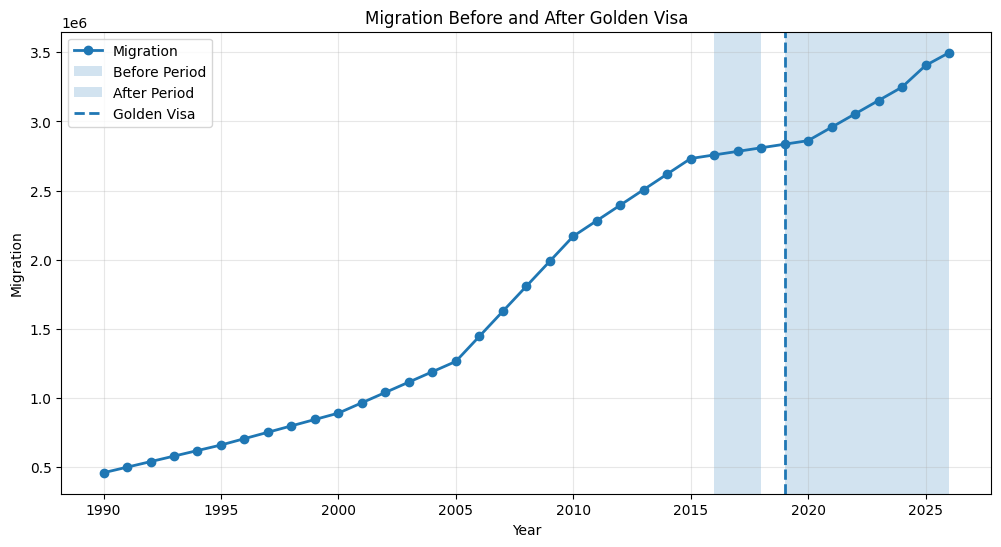

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["Year"], df["Migration"],
         marker='o',
         linewidth=2,
         label="Migration")

# Highlight before
plt.axvspan(2016, 2018,
            alpha=0.2,
            label="Before Period")

# Highlight after
plt.axvspan(2019, df["Year"].max(),
            alpha=0.2,
            label="After Period")

# Policy year
plt.axvline(2019,
            linestyle='--',
            linewidth=2,
            label="Golden Visa")

plt.title("Migration Before and After Golden Visa")
plt.xlabel("Year")
plt.ylabel("Migration")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

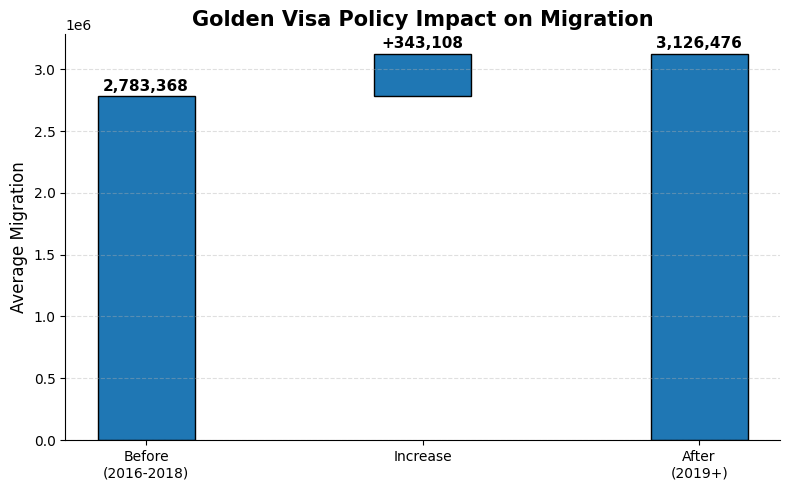

In [ ]:
import matplotlib.pyplot as plt

# Difference
increase = after_avg - before_avg

# Data
labels = ["Before\n(2016-2018)", "Increase", "After\n(2019+)"]
values = [before_avg, increase, after_avg]
bottoms = [0, before_avg, 0]

plt.figure(figsize=(8,5))

# Create bars (small width)
bars = plt.bar(
    labels,
    values,
    bottom=bottoms,
    width=0.35,
    edgecolor='black',
    linewidth=1
)

# Add value labels
plt.text(
    0,
    before_avg + before_avg*0.015,
    f"{before_avg:,.0f}",
    ha='center',
    fontsize=11,
    fontweight='bold'
)

plt.text(
    1,
    before_avg + increase + before_avg*0.015,
    f"+{increase:,.0f}",
    ha='center',
    fontsize=11,
    fontweight='bold'
)

plt.text(
    2,
    after_avg + before_avg*0.015,
    f"{after_avg:,.0f}",
    ha='center',
    fontsize=11,
    fontweight='bold'
)

# Titles
plt.title(
    "Golden Visa Policy Impact on Migration",
    fontsize=15,
    fontweight='bold'
)

plt.ylabel("Average Migration", fontsize=12)

# Clean style
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

ITS

ITS for first policy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [ ]:
import pandas as pd
df=pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")
df.tail(20)

,Country,Year,GDP,Inflation,Population,Migration,Migration_Flow,Oil_Price,Exchange_Rate,Unemployment,...,Labor_Mobility_Reform,Saudization_Nitaqat,Vision2030,Labor_Reform_Initiative,Expat_Levy,Emiratisation_Policy,Golden_Visa,Entry_Residence_Law,Domestic_Workers_Law,Employment_Contract_Reform
128,United Arab Emirates,2007,257.883,1.561813,5.595,1625057,210000,72.44,0.272294,2.917,...,0,0,0,0,0,1,0,0,0,0
129,United Arab Emirates,2008,315.464,1.561813,6.498,1806323,185000,96.94,0.272294,2.795,...,0,0,0,0,0,1,0,0,0,0
130,United Arab Emirates,2009,253.547,1.561813,6.774,1987590,130000,61.74,0.272294,2.887,...,0,0,0,0,0,1,0,0,0,0
131,United Arab Emirates,2010,307.736,0.877983,6.965,2168857,145000,79.61,0.272294,2.756,...,0,0,0,0,0,1,0,0,0,0
132,United Arab Emirates,2011,368.881,0.877347,7.244,2281402,148000,111.26,0.272294,2.544,...,0,0,0,0,0,1,0,0,0,0
133,United Arab Emirates,2012,392.793,0.662269,7.539,2393947,150000,111.63,0.272294,2.256,...,0,0,0,0,0,1,0,0,0,0
134,United Arab Emirates,2013,409.633,1.101118,7.847,2506493,142000,108.56,0.272294,2.070,...,0,0,0,0,0,1,0,0,0,0
135,United Arab Emirates,2014,424.936,2.346269,8.272,2619038,135000,98.97,0.272294,1.956,...,0,0,0,0,0,1,0,0,0,0
136,United Arab Emirates,2015,381.973,4.069966,8.738,2731583,120000,52.32,0.272294,1.789,...,0,0,0,0,0,1,0,0,0,0
137,United Arab Emirates,2016,381.717,1.617488,9.132,2757475,110000,43.64,0.272294,1.640,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
print(df["Country"].unique())


['India' 'Qatar' 'Saudi Arabia' 'United Arab Emirates']


In [ ]:
df["Country"] = df["Country"].astype(str).str.strip()

In [ ]:
uae = df[df["Country"] == "United Arab Emirates"].copy()

In [ ]:
print(uae.shape)
uae.head()

(37, 24)


,Country,Year,GDP,Inflation,Population,Migration,Migration_Flow,Oil_Price,Exchange_Rate,Unemployment,...,Labor_Mobility_Reform,Saudization_Nitaqat,Vision2030,Labor_Reform_Initiative,Expat_Levy,Emiratisation_Policy,Golden_Visa,Entry_Residence_Law,Domestic_Workers_Law,Employment_Contract_Reform
111,United Arab Emirates,1990,50.682,1.561813,1.844,456794,55000,23.76,0.272405,1.660,...,0,0,0,0,0,0,0,0,0,0
112,United Arab Emirates,1991,49.300,1.561813,1.928,496911,60000,20.04,0.272405,1.660,...,0,0,0,0,0,0,0,0,0,0
113,United Arab Emirates,1992,51.952,1.561813,2.011,537028,65000,19.32,0.272405,1.737,...,0,0,0,0,0,0,0,0,0,0
114,United Arab Emirates,1993,52.144,1.561813,2.083,577146,68000,17.01,0.272405,1.907,...,0,0,0,0,0,0,0,0,0,0
115,United Arab Emirates,1994,57.395,1.561813,2.230,617263,72000,15.86,0.272405,1.838,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
uae = uae.sort_values("Year").reset_index(drop=True)

In [ ]:
uae["Time"] = range(1, len(uae) + 1)

In [ ]:
uae[["Year", "Time"]]


,Year,Time
0,1990,1
1,1991,2
2,1992,3
3,1993,4
4,1994,5
5,1995,6
6,1996,7
7,1997,8
8,1998,9
9,1999,10


In [ ]:
uae["Policy"] = uae["Emiratisation_Policy"]

In [ ]:

uae[["Year", "Policy"]]

,Year,Policy
0,1990,0
1,1991,0
2,1992,0
3,1993,0
4,1994,0
5,1995,0
6,1996,0
7,1997,0
8,1998,0
9,1999,0


In [ ]:


uae["Time_After"] = 0

policy_index = uae[uae["Policy"] == 1].index[0]

uae.loc[policy_index:, "Time_After"] = range(
    1,
    len(uae) - policy_index + 1
)

In [ ]:
uae[["Year", "Policy", "Time_After"]]

,Year,Policy,Time_After
0,1990,0,0
1,1991,0,0
2,1992,0,0
3,1993,0,0
4,1994,0,0
5,1995,0,0
6,1996,0,0
7,1997,0,0
8,1998,0,0
9,1999,0,0


In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Migration ~ Time + Policy + Time_After",
    data=uae
).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     860.9
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           2.15e-31
Time:                        16:07:00   Log-Likelihood:                -482.82
No. Observations:                  37   AIC:                             973.6
Df Residuals:                      33   BIC:                             980.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    3.71e+05   6.47e+04      5.735      0.0

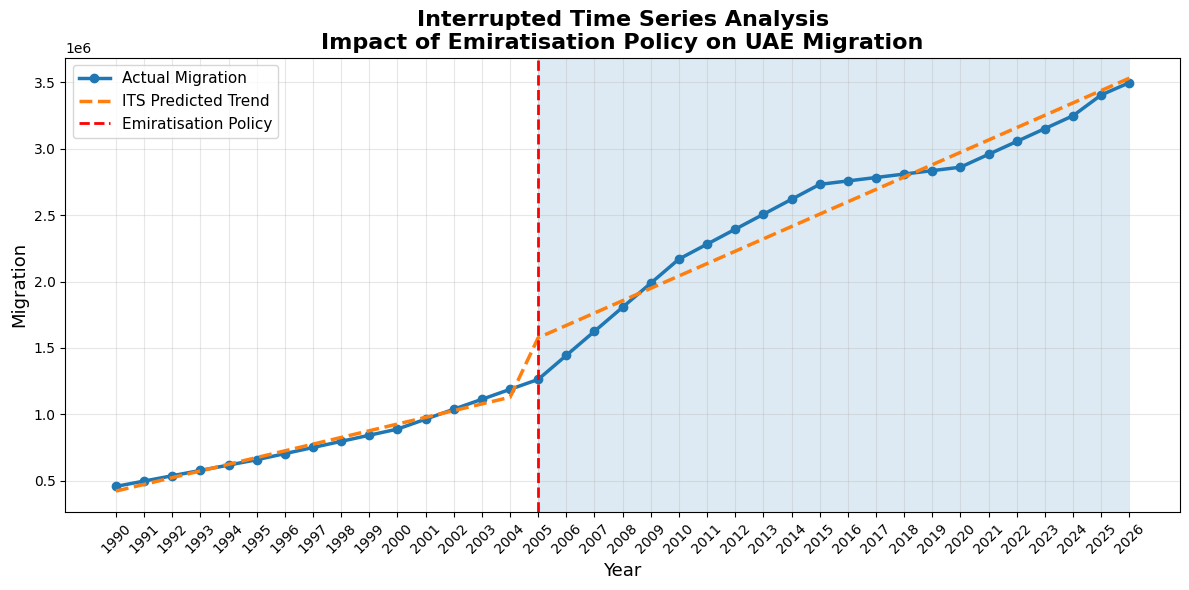

In [ ]:
# Predicted values
uae["Predicted"] = model.predict(uae)

# Policy Year
policy_year = uae.loc[policy_index, "Year"]

plt.figure(figsize=(12,6))

# Actual Migration
plt.plot(
    uae["Year"],
    uae["Migration"],
    marker="o",
    linewidth=2.5,
    label="Actual Migration"
)

# ITS Prediction
plt.plot(
    uae["Year"],
    uae["Predicted"],
    linestyle="--",
    linewidth=2.5,
    label="ITS Predicted Trend"
)

# Policy Line
plt.axvline(
    x=policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Emiratisation Policy"
)

# Shade Post-Policy Period
plt.axvspan(
    policy_year,
    uae["Year"].max(),
    alpha=0.15
)

plt.title("Interrupted Time Series Analysis\nImpact of Emiratisation Policy on UAE Migration",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Year", fontsize=13)
plt.ylabel("Migration", fontsize=13)

plt.xticks(uae["Year"], rotation=45)

plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

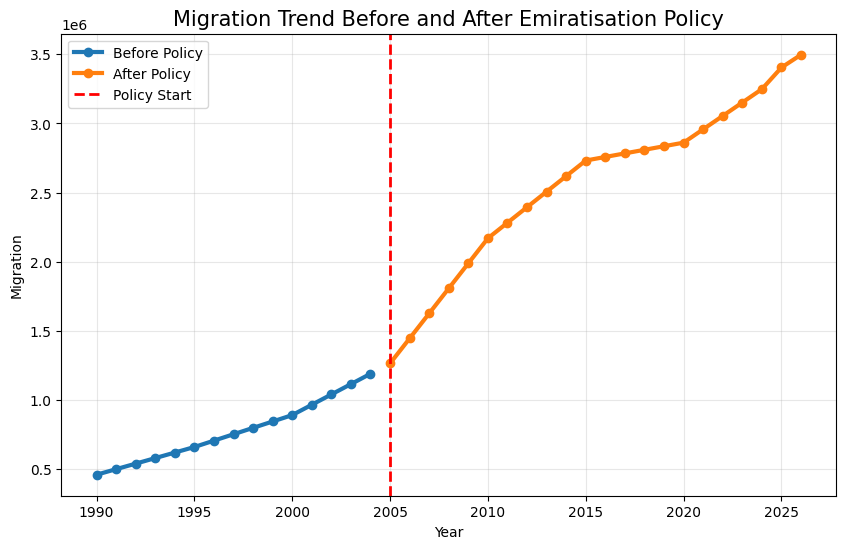

In [ ]:
plt.figure(figsize=(10,6))

before = uae[uae["Policy"] == 0]
after = uae[uae["Policy"] == 1]

plt.plot(before["Year"], before["Migration"],
         marker='o', linewidth=3,
         label="Before Policy")

plt.plot(after["Year"], after["Migration"],
         marker='o', linewidth=3,
         label="After Policy")

plt.axvline(policy_year,
            color='red',
            linestyle='--',
            linewidth=2,
            label='Policy Start')

plt.title("Migration Trend Before and After Emiratisation Policy",
          fontsize=15)

plt.xlabel("Year")
plt.ylabel("Migration")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

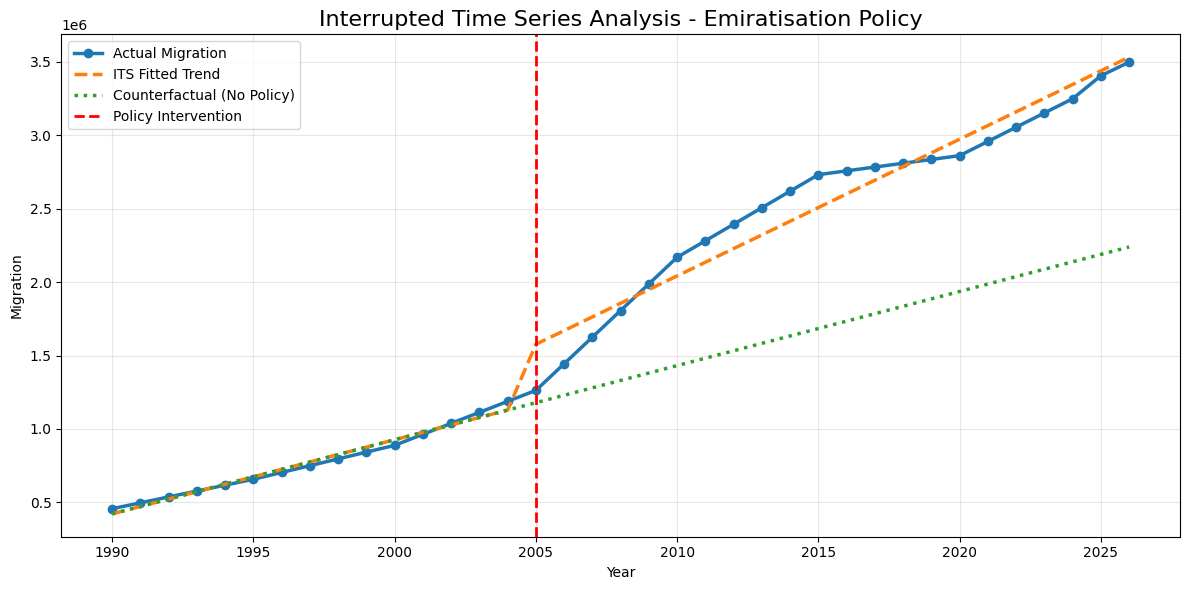

In [ ]:

# Predict using the ITS model
uae["ITS_Fit"] = model.predict(uae)

# Counterfactual (trend if policy had never occurred)
uae["Counterfactual"] = (
    model.params["Intercept"] +
    model.params["Time"] * uae["Time"]
)

plt.figure(figsize=(12,6))

plt.plot(
    uae["Year"],
    uae["Migration"],
    'o-',
    linewidth=2.5,
    label="Actual Migration"
)

plt.plot(
    uae["Year"],
    uae["ITS_Fit"],
    '--',
    linewidth=2.5,
    label="ITS Fitted Trend"
)

plt.plot(
    uae["Year"],
    uae["Counterfactual"],
    ':',
    linewidth=2.5,
    label="Counterfactual (No Policy)"
)

plt.axvline(
    policy_year,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Policy Intervention'
)

plt.title("Interrupted Time Series Analysis - Emiratisation Policy",
          fontsize=16)

plt.xlabel("Year")
plt.ylabel("Migration")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Golden Visa Policy (0 = Before, 1 = After)
uae["Policy"] = uae["Golden_Visa"]

# Check
uae[["Year", "Policy"]]

,Year,Policy
0,1990,0
1,1991,0
2,1992,0
3,1993,0
4,1994,0
5,1995,0
6,1996,0
7,1997,0
8,1998,0
9,1999,0


In [ ]:
# Initialize
uae["Time_After"] = 0

# Find the first year when the policy starts
policy_index = uae[uae["Policy"] == 1].index[0]

# Create Time_After
uae.loc[policy_index:, "Time_After"] = range(
    1,
    len(uae) - policy_index + 1
)

# Check
uae[["Year", "Policy", "Time_After"]]

,Year,Policy,Time_After
0,1990,0,0
1,1991,0,0
2,1992,0,0
3,1993,0,0
4,1994,0,0
5,1995,0,0
6,1996,0,0
7,1997,0,0
8,1998,0,0
9,1999,0,0


In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "Migration ~ Time + Policy + Time_After",
    data=uae
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     415.6
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           2.84e-26
Time:                        16:07:20   Log-Likelihood:                -496.05
No. Observations:                  37   AIC:                             1000.
Df Residuals:                      33   BIC:                             1007.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.878e+04   6.49e+04      0.598      0.5

ITS Golden visa

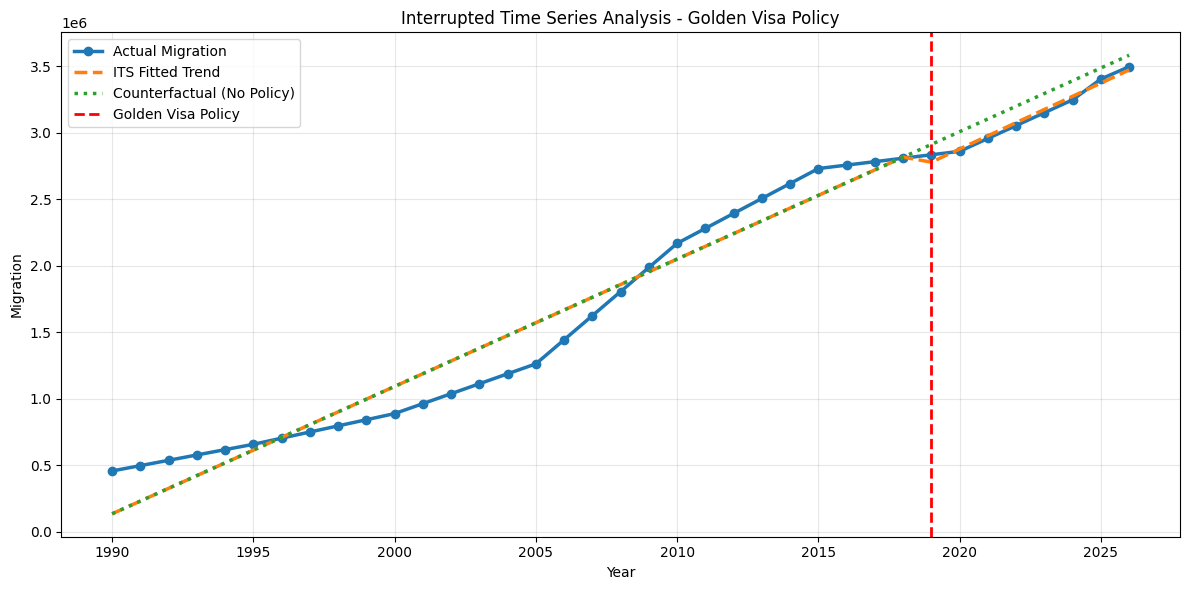

In [ ]:
# Predicted values
uae["ITS_Fit"] = model.predict(uae)

# Counterfactual (No Policy)
uae["Counterfactual"] = (
    model.params["Intercept"] +
    model.params["Time"] * uae["Time"]
)

# Policy Year
policy_year = uae.loc[policy_index, "Year"]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(uae["Year"], uae["Migration"],
         marker='o',
         linewidth=2.5,
         label="Actual Migration")

plt.plot(uae["Year"], uae["ITS_Fit"],
         '--',
         linewidth=2.5,
         label="ITS Fitted Trend")

plt.plot(uae["Year"], uae["Counterfactual"],
         ':',
         linewidth=2.5,
         label="Counterfactual (No Policy)")

plt.axvline(policy_year,
            color='red',
            linestyle='--',
            linewidth=2,
            label='Golden Visa Policy')

plt.title("Interrupted Time Series Analysis - Golden Visa Policy")
plt.xlabel("Year")
plt.ylabel("Migration")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

analysis for 3rd policy

In [ ]:
import pandas as pd
df=pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")
df.tail()

,Country,Year,GDP,Inflation,Population,Migration,Migration_Flow,Oil_Price,Exchange_Rate,Unemployment,...,Labor_Mobility_Reform,Saudization_Nitaqat,Vision2030,Labor_Reform_Initiative,Expat_Levy,Emiratisation_Policy,Golden_Visa,Entry_Residence_Law,Domestic_Workers_Law,Employment_Contract_Reform
143,United Arab Emirates,2022,511.403,5.291226,10.289,3054795,90000,100.93,0.272294,2.873,...,0,0,0,0,0,1,1,1,1,1
144,United Arab Emirates,2023,522.622,1.626708,10.679,3151670,105000,82.49,0.272294,2.953,...,0,0,0,0,0,1,1,1,1,1
145,United Arab Emirates,2024,552.325,1.663365,11.294,3248545,115000,80.52,0.272294,2.953,...,0,0,0,0,0,1,1,1,1,1
146,United Arab Emirates,2025,571.643,1.250865,11.380,3405095,115000,69.14,0.272294,2.953,...,0,0,0,0,0,1,1,1,1,1
147,United Arab Emirates,2026,621.546,1.250865,11.465,3497584,115000,69.14,0.272294,2.953,...,0,0,0,0,0,1,1,1,1,1


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# Filter UAE
uae = df[df["Country"] == "United Arab Emirates"].copy()

# Sort by Year
uae = uae.sort_values("Year").reset_index(drop=True)

print(uae.head())

                Country  Year     GDP  Inflation  Population  Migration  \
0  United Arab Emirates  1990  50.682   1.561813       1.844     456794   
1  United Arab Emirates  1991  49.300   1.561813       1.928     496911   
2  United Arab Emirates  1992  51.952   1.561813       2.011     537028   
3  United Arab Emirates  1993  52.144   1.561813       2.083     577146   
4  United Arab Emirates  1994  57.395   1.561813       2.230     617263   

   Migration_Flow  Oil_Price  Exchange_Rate  Unemployment  ...  \
0           55000      23.76       0.272405         1.660  ...   
1           60000      20.04       0.272405         1.660  ...   
2           65000      19.32       0.272405         1.737  ...   
3           68000      17.01       0.272405         1.907  ...   
4           72000      15.86       0.272405         1.838  ...   

   Labor_Mobility_Reform  Saudization_Nitaqat  Vision2030  \
0                      0                    0           0   
1                      0      

In [ ]:
policy_year = uae.loc[
    uae["Entry_Residence_Law"]==1,
    "Year"
].min()

print(policy_year)

2021


In [ ]:
before = uae[
    (uae["Year"]>=policy_year-3) &
    (uae["Year"]<policy_year)
]

after = uae[
    uae["Year"]>=policy_year
]

In [ ]:
before_avg = before["Migration"].mean()
after_avg = after["Migration"].mean()

increase = after_avg-before_avg

percentage=((increase)/before_avg)*100

print("Average Before :",before_avg)
print("Average After :",after_avg)
print("Increase :",increase)
print("Percentage :",percentage)

Average Before : 2835152.6666666665
Average After : 3219268.1666666665
Increase : 384115.5
Percentage : 13.548318032961895


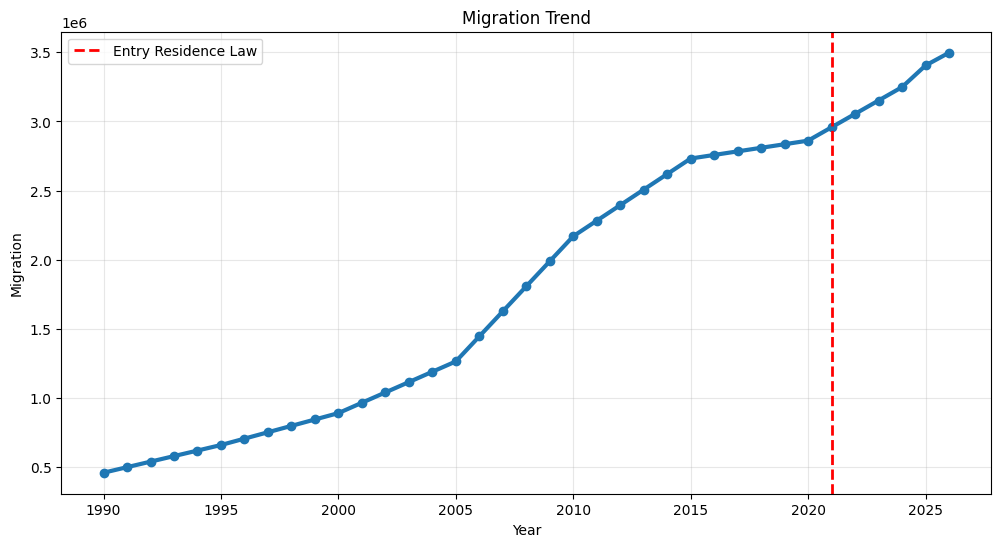

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    uae["Year"],
    uae["Migration"],
    marker="o",
    linewidth=3
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Entry Residence Law"
)

plt.title("Migration Trend")
plt.xlabel("Year")
plt.ylabel("Migration")
plt.legend()

plt.grid(alpha=.3)

plt.show()

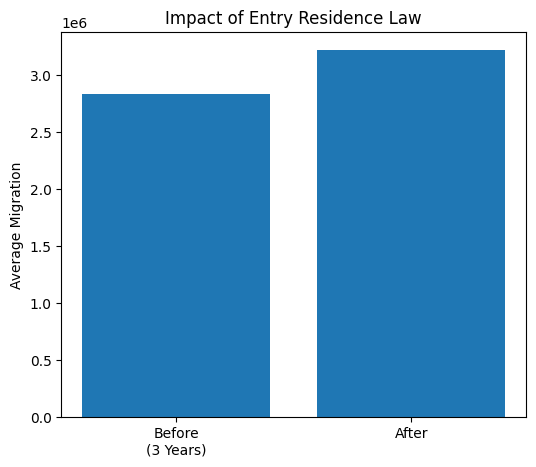

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Before\n(3 Years)","After"],
    [before_avg,after_avg]
)

plt.ylabel("Average Migration")

plt.title("Impact of Entry Residence Law")

plt.show()

/tmp/ipykernel_829/225953233.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


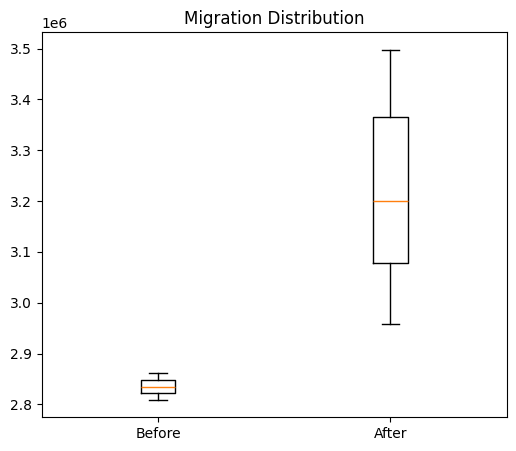

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot([
    before["Migration"],
    after["Migration"]
],
labels=["Before","After"])

plt.title("Migration Distribution")

plt.show()

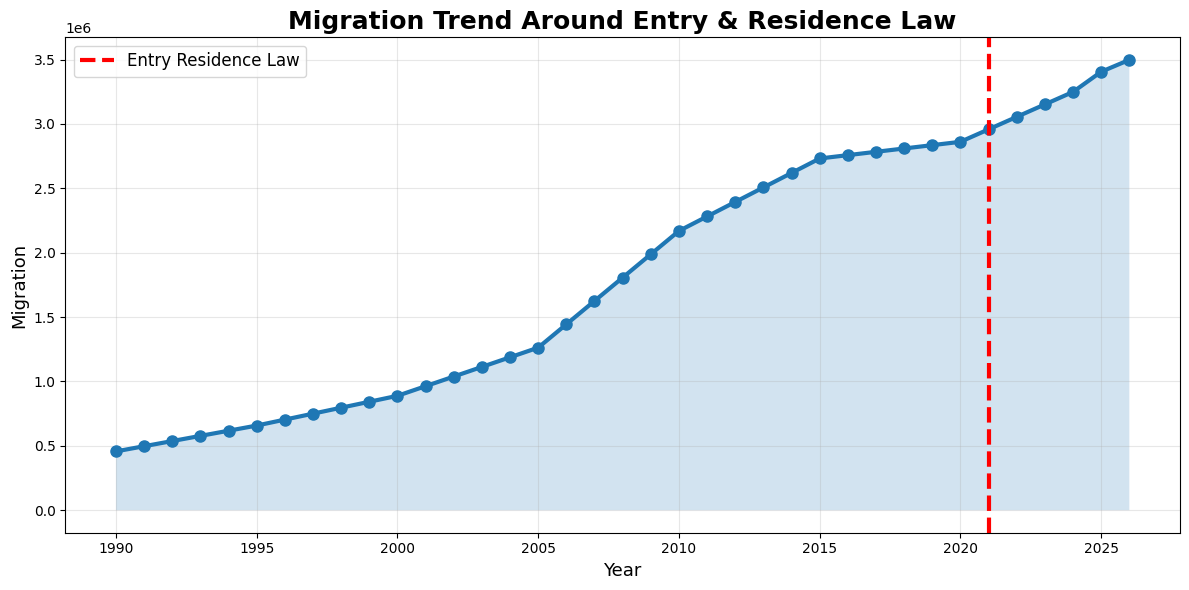

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    uae["Year"],
    uae["Migration"],
    marker="o",
    linewidth=3,
    markersize=8
)

plt.fill_between(
    uae["Year"],
    uae["Migration"],
    alpha=.2
)

plt.axvline(
    policy_year,
    color="red",
    linewidth=3,
    linestyle="--",
    label="Entry Residence Law"
)

plt.xlabel("Year",fontsize=13)

plt.ylabel("Migration",fontsize=13)

plt.title(
    "Migration Trend Around Entry & Residence Law",
    fontsize=18,
    weight="bold"
)

plt.legend(fontsize=12)

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

PCA using multiple linear regresion

In [ ]:
X = uae[
[
"GDP",
"Inflation",
"Population",
"Oil_Price",
"Exchange_Rate",
"Unemployment"
]
]

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf
scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)


In [ ]:
pca = PCA(n_components=0.95)

PC = pca.fit_transform(X_scaled)

print("Components :",pca.n_components_)

Components : 4


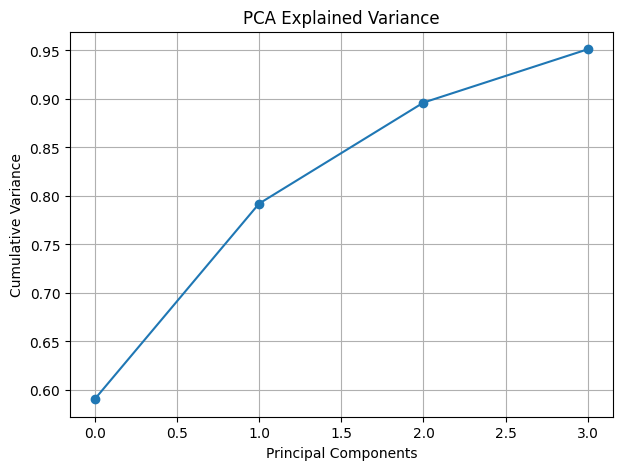

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Principal Components")

plt.ylabel("Cumulative Variance")

plt.title("PCA Explained Variance")

plt.grid()

plt.show()

In [ ]:
pc_df = pd.DataFrame(PC)

pc_df.columns=[
f"PC{i+1}"
for i in range(pc_df.shape[1])
]

uae=uae.reset_index(drop=True)

reg=pd.concat([uae,pc_df],axis=1)

In [ ]:
formula="Migration ~ Entry_Residence_Law"

for col in pc_df.columns:
    formula+=" + "+col

model=smf.ols(formula,data=reg).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     187.2
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           3.41e-22
Time:                        16:07:45   Log-Likelihood:                -500.07
No. Observations:                  37   AIC:                             1012.
Df Residuals:                      31   BIC:                             1022.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.866e+06   3

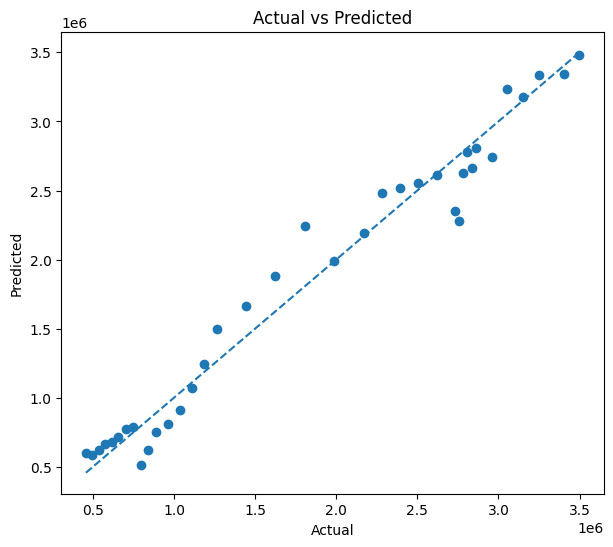

In [ ]:
pred=model.predict(reg)

plt.figure(figsize=(7,6))

plt.scatter(
    reg["Migration"],
    pred
)

plt.plot(
[
reg["Migration"].min(),
reg["Migration"].max()
],
[
reg["Migration"].min(),
reg["Migration"].max()
],
linestyle="--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

ITS

In [ ]:
uae["Time"]=range(1,len(uae)+1)

uae["Policy"]=(uae["Year"]>=policy_year).astype(int)

uae["Time_After"]=(
uae["Year"]-policy_year+1
)

uae.loc[
uae["Year"]<policy_year,
"Time_After"
]=0

In [ ]:
its=smf.ols(
"Migration~Time+Policy+Time_After",
data=uae
).fit()

print(its.summary())


                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     408.5
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           3.74e-26
Time:                        16:07:49   Log-Likelihood:                -496.36
No. Observations:                  37   AIC:                             1001.
Df Residuals:                      33   BIC:                             1007.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.284e+04   6.32e+04      0.836      0.4

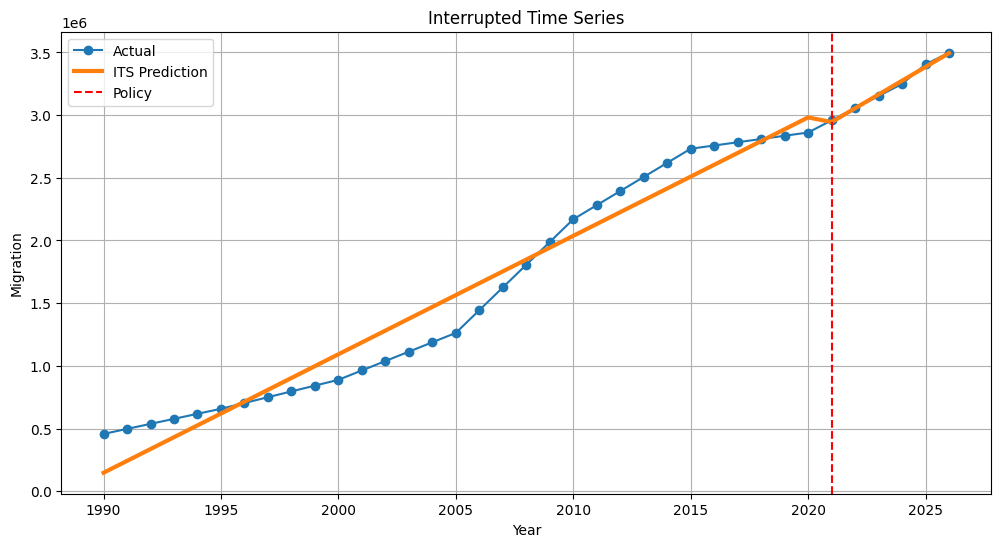

In [ ]:
uae["Prediction"]=its.predict(uae)

plt.figure(figsize=(12,6))

plt.plot(
uae["Year"],
uae["Migration"],
marker="o",
label="Actual"
)

plt.plot(
uae["Year"],
uae["Prediction"],
linewidth=3,
label="ITS Prediction"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
label="Policy"
)

plt.legend()

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Interrupted Time Series")

plt.grid()

plt.show()


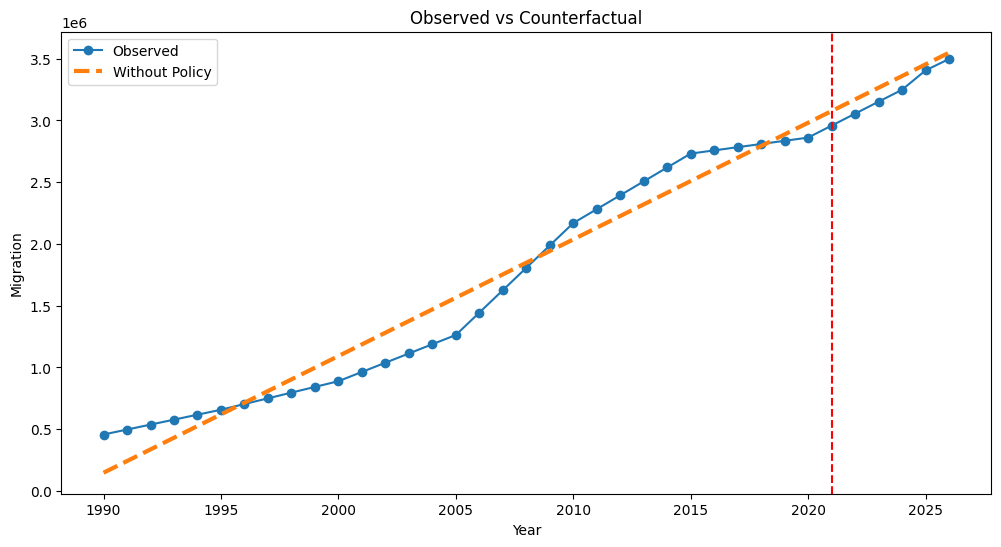

In [ ]:
counter=uae.copy()

counter["Policy"]=0
counter["Time_After"]=0

counter_pred=its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(
uae["Year"],
uae["Migration"],
marker="o",
label="Observed"
)

plt.plot(
uae["Year"],
counter_pred,
linestyle="--",
linewidth=3,
label="Without Policy"
)

plt.axvline(
policy_year,
color="red",
linestyle="--"
)

plt.legend()

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.show()

multiple linear regression pca for entry and residance policy

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# UAE only
uae = df[df["Country"]=="United Arab Emirates"].copy()

uae = uae.sort_values("Year").reset_index(drop=True)

# Economic variables
economic = [
    #"GDP",
    #"Population",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"
]

X = uae[economic]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=0.95)

PC = pca.fit_transform(X_scaled)

# PCA dataframe
pc_df = pd.DataFrame(
    PC,
    columns=[f"PC{i+1}" for i in range(PC.shape[1])]
)

# Combine
data = pd.concat(
    [uae, pc_df],
    axis=1
)

print(pca.explained_variance_ratio_)

[0.51580693 0.28172004 0.1274992  0.07497383]


In [ ]:
import statsmodels.formula.api as smf

formula = "Migration ~ Entry_Residence_Law"

for col in pc_df.columns:
    formula += " + " + col

model = smf.ols(
    formula=formula,
    data=data
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     21.24
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           3.50e-09
Time:                        16:07:56   Log-Likelihood:                -536.20
No. Observations:                  37   AIC:                             1084.
Df Residuals:                      31   BIC:                             1094.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.634e+06   9

Domestic_Workers_Law

In [ ]:
import pandas as pd
df=pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")
df.tail(20)

,Country,Year,GDP,Inflation,Population,Migration,Migration_Flow,Oil_Price,Exchange_Rate,Unemployment,...,Labor_Mobility_Reform,Saudization_Nitaqat,Vision2030,Labor_Reform_Initiative,Expat_Levy,Emiratisation_Policy,Golden_Visa,Entry_Residence_Law,Domestic_Workers_Law,Employment_Contract_Reform
128,United Arab Emirates,2007,257.883,1.561813,5.595,1625057,210000,72.44,0.272294,2.917,...,0,0,0,0,0,1,0,0,0,0
129,United Arab Emirates,2008,315.464,1.561813,6.498,1806323,185000,96.94,0.272294,2.795,...,0,0,0,0,0,1,0,0,0,0
130,United Arab Emirates,2009,253.547,1.561813,6.774,1987590,130000,61.74,0.272294,2.887,...,0,0,0,0,0,1,0,0,0,0
131,United Arab Emirates,2010,307.736,0.877983,6.965,2168857,145000,79.61,0.272294,2.756,...,0,0,0,0,0,1,0,0,0,0
132,United Arab Emirates,2011,368.881,0.877347,7.244,2281402,148000,111.26,0.272294,2.544,...,0,0,0,0,0,1,0,0,0,0
133,United Arab Emirates,2012,392.793,0.662269,7.539,2393947,150000,111.63,0.272294,2.256,...,0,0,0,0,0,1,0,0,0,0
134,United Arab Emirates,2013,409.633,1.101118,7.847,2506493,142000,108.56,0.272294,2.070,...,0,0,0,0,0,1,0,0,0,0
135,United Arab Emirates,2014,424.936,2.346269,8.272,2619038,135000,98.97,0.272294,1.956,...,0,0,0,0,0,1,0,0,0,0
136,United Arab Emirates,2015,381.973,4.069966,8.738,2731583,120000,52.32,0.272294,1.789,...,0,0,0,0,0,1,0,0,0,0
137,United Arab Emirates,2016,381.717,1.617488,9.132,2757475,110000,43.64,0.272294,1.640,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import statsmodels.formula.api as smf

# Read dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")
# Check country names
print(df["Country"].unique())

# CHANGE THIS TO MATCH YOUR DATASET
uae = df[df["Country"]=="United Arab Emirates"].copy()

uae = uae.sort_values("Year").reset_index(drop=True)


print("Rows :", len(uae))

['India' 'Qatar' 'Saudi Arabia' 'United Arab Emirates']
Rows : 37


In [ ]:
economic = [
    #"GDP",
    #"Population",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"
]

# Remove missing values
uae = uae.dropna(
    subset=economic + ["Migration","Domestic_Workers_Law"]
)

X = uae[economic]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)

PC = pca.fit_transform(X_scaled)

pc_df = pd.DataFrame(
    PC,
    columns=[f"PC{i+1}" for i in range(PC.shape[1])]
)

data = pd.concat(
    [uae.reset_index(drop=True), pc_df],
    axis=1
)

In [ ]:
formula = "Migration ~ Domestic_Workers_Law"

for col in pc_df.columns:
    formula += " + " + col

model = smf.ols(
    formula,
    data=data
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     19.59
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           8.91e-09
Time:                        05:37:30   Log-Likelihood:                -537.35
No. Observations:                  37   AIC:                             1087.
Df Residuals:                      31   BIC:                             1096.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1.662e+06 

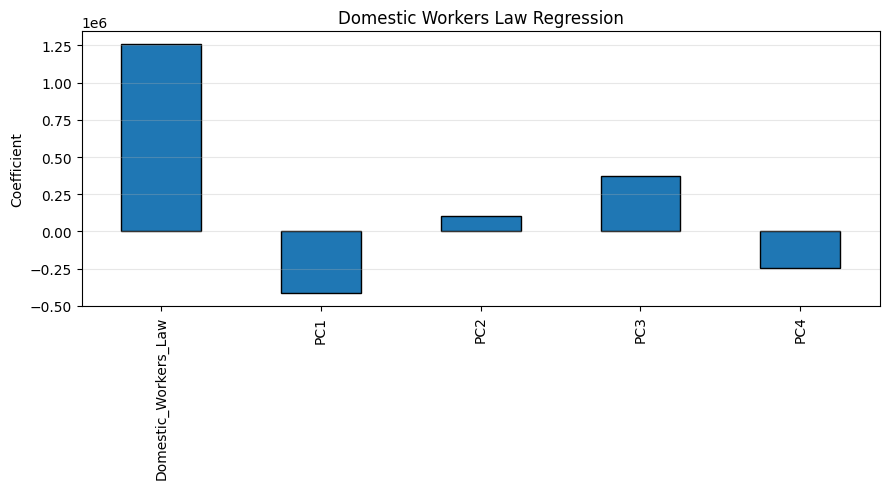

In [ ]:
import matplotlib.pyplot as plt

coef = model.params.drop("Intercept")

plt.figure(figsize=(9,5))

coef.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Domestic Workers Law Regression")

plt.ylabel("Coefficient")

plt.grid(axis="y",alpha=.3)

plt.tight_layout()

plt.show()

descriptive analysis for 4 policy

```
# This is formatted as code
```



In [ ]:
df.tail(50)

,Country,Year,GDP,Inflation,Population,Migration,Migration_Flow,Oil_Price,Exchange_Rate,Unemployment,...,Labor_Mobility_Reform,Saudization_Nitaqat,Vision2030,Labor_Reform_Initiative,Expat_Levy,Emiratisation_Policy,Golden_Visa,Entry_Residence_Law,Domestic_Workers_Law,Employment_Contract_Reform
98,Saudi Arabia,2014,787.153,2.241853,28.309,1839235,320000,98.97,0.266667,5.877,...,0,1,0,0,0,0,0,0,0,0
99,Saudi Arabia,2015,693.415,1.222693,29.816,1920159,250000,52.32,0.266667,5.600,...,0,1,0,0,0,0,0,0,0,0
100,Saudi Arabia,2016,689.279,2.053471,30.954,1913745,200000,43.64,0.266667,5.600,...,0,1,1,0,0,0,0,0,0,0
101,Saudi Arabia,2017,741.266,-0.834846,30.977,1907331,188000,54.13,0.266667,5.890,...,0,1,1,0,1,0,0,0,0,0
102,Saudi Arabia,2018,886.564,2.465943,30.196,1900918,180000,71.34,0.266667,6.029,...,0,1,1,0,1,0,0,0,0,0
103,Saudi Arabia,2019,888.888,-1.192986,30.064,1894504,190000,64.30,0.266667,5.636,...,0,1,1,0,1,0,0,0,0,0
104,Saudi Arabia,2020,767.303,3.372350,31.553,1888090,70000,41.96,0.266667,7.660,...,0,1,1,0,1,0,0,0,0,0
105,Saudi Arabia,2021,982.661,3.063290,30.784,1904442,110000,70.86,0.266667,6.620,...,0,1,1,1,1,0,0,0,0,0
106,Saudi Arabia,2022,1239.075,2.474074,32.175,1920793,170000,100.93,0.266667,5.590,...,0,1,1,1,1,0,0,0,0,0
107,Saudi Arabia,2023,1218.585,2.327085,33.703,1937144,195000,82.49,0.266667,5.007,...,0,1,1,1,1,0,0,0,0,0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# Select UAE
uae = df[df["Country"]=="United Arab Emirates"].copy()

uae = uae.sort_values("Year").reset_index(drop=True)

In [ ]:
policy = "Domestic_Workers_Law"

# Other examples
# policy = "Golden_Visa"
# policy = "Entry_Residence_Law"
# policy = "Employment_Contract_Reform"
# policy = "Emiratisation_Policy"

policy_year = uae.loc[
    uae[policy] == 1,
    "Year"
].min()

print("Policy :", policy)
print("Policy Year :", policy_year)

Policy : Domestic_Workers_Law
Policy Year : 2022


In [ ]:
before = uae[
    (uae["Year"] >= policy_year-3) &
    (uae["Year"] < policy_year)
]

after = uae[
    uae["Year"] >= policy_year
]

In [ ]:
before_avg = before["Migration"].mean()

after_avg = after["Migration"].mean()

increase = after_avg-before_avg

percent=(increase/before_avg)*100

print("Average Before :",round(before_avg,2))

print("Average After :",round(after_avg,2))

print("Increase :",round(increase,2))

print("Percentage Increase :",round(percent,2),"%")

Average Before : 2884706.0
Average After : 3271537.8
Increase : 386831.8
Percentage Increase : 13.41 %


In [ ]:
summary=pd.DataFrame({

"Period":[
"Before (3 Years)",
"After (All Years)"
],

"Average Migration":[
before_avg,
after_avg
],

"Observations":[
len(before),
len(after)
]

})

print(summary)

              Period  Average Migration  Observations
0   Before (3 Years)          2884706.0             3
1  After (All Years)          3271537.8             5


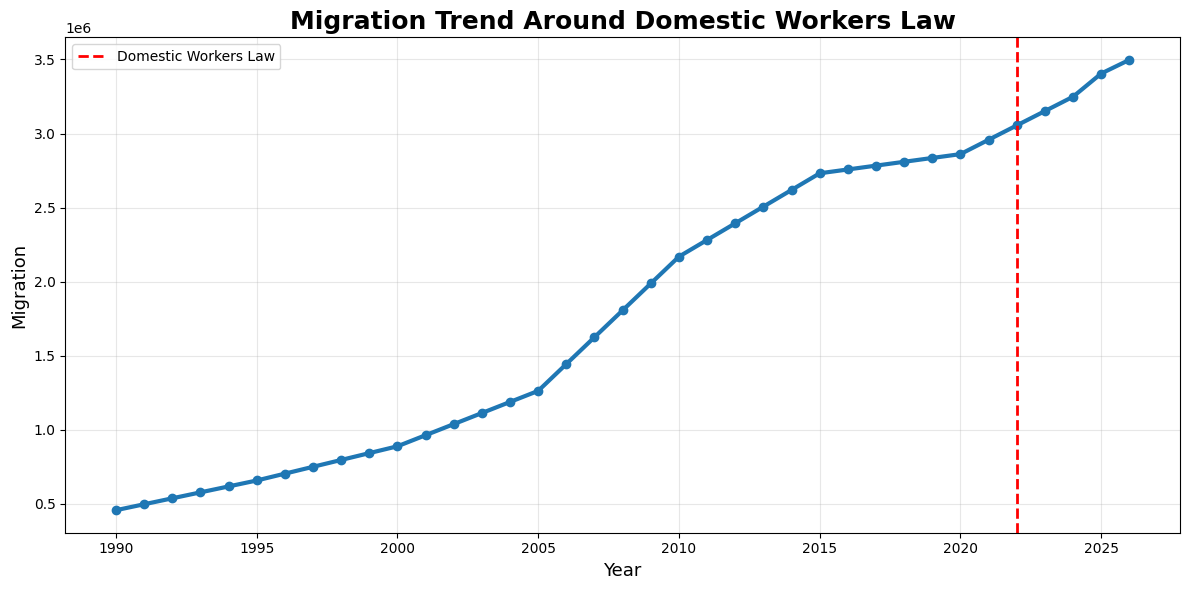

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    uae["Year"],
    uae["Migration"],
    marker='o',
    linewidth=3
)

plt.axvline(
    policy_year,
    color='red',
    linestyle='--',
    linewidth=2,
    label=policy.replace("_"," ")
)

plt.title(
    f"Migration Trend Around {policy.replace('_',' ')}",
    fontsize=18,
    weight='bold'
)

plt.xlabel("Year",fontsize=13)

plt.ylabel("Migration",fontsize=13)

plt.legend()

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

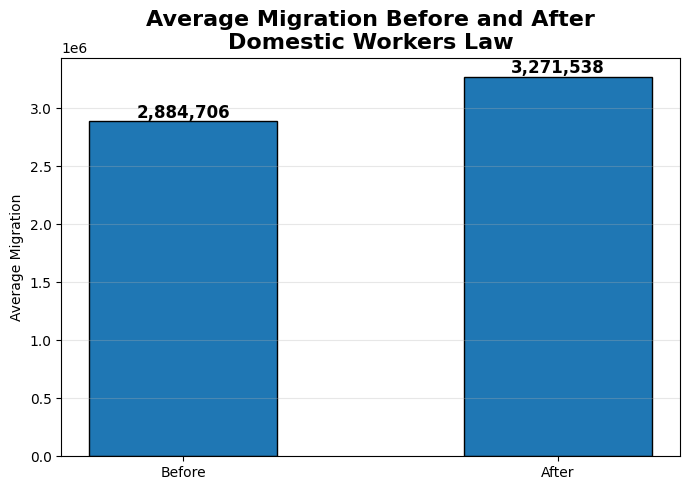

In [ ]:
fig,ax=plt.subplots(figsize=(7,5))

bars=ax.bar(
    ["Before","After"],
    [before_avg,after_avg],
    width=.5,
    edgecolor="black"
)

for bar in bars:

    h=bar.get_height()

    ax.text(
        bar.get_x()+bar.get_width()/2,
        h*1.01,
        f"{h:,.0f}",
        ha='center',
        fontsize=12,
        weight='bold'
    )

ax.set_ylabel("Average Migration")

ax.set_title(
    f"Average Migration Before and After\n{policy.replace('_',' ')}",
    fontsize=16,
    weight='bold'
)

ax.grid(axis='y',alpha=.3)

plt.tight_layout()

plt.show()

ITS for method for 4th policy

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# UAE
uae = df[df["Country"]=="United Arab Emirates"].copy()

uae = uae.sort_values("Year").reset_index(drop=True)

policy = "Domestic_Workers_Law"

policy_year = uae.loc[
    uae[policy]==1,
    "Year"
].min()

print(policy_year)

2022


In [ ]:
uae["Time"] = range(1,len(uae)+1)

uae["Policy"] = (
    uae["Year"]>=policy_year
).astype(int)

uae["Time_After"] = (
    uae["Year"]-policy_year+1
)

uae.loc[
    uae["Year"]<policy_year,
    "Time_After"
]=0

print(
uae[
["Year","Time","Policy","Time_After"]
].tail()
)

    Year  Time  Policy  Time_After
32  2022    33       1           1
33  2023    34       1           2
34  2024    35       1           3
35  2025    36       1           4
36  2026    37       1           5


In [ ]:
its = smf.ols(
"Migration ~ Time + Policy + Time_After",
data=uae
).fit()

print(its.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     403.4
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           4.58e-26
Time:                        05:39:08   Log-Likelihood:                -496.58
No. Observations:                  37   AIC:                             1001.
Df Residuals:                      33   BIC:                             1008.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.022e+04   6.25e+04      0.963      0.3

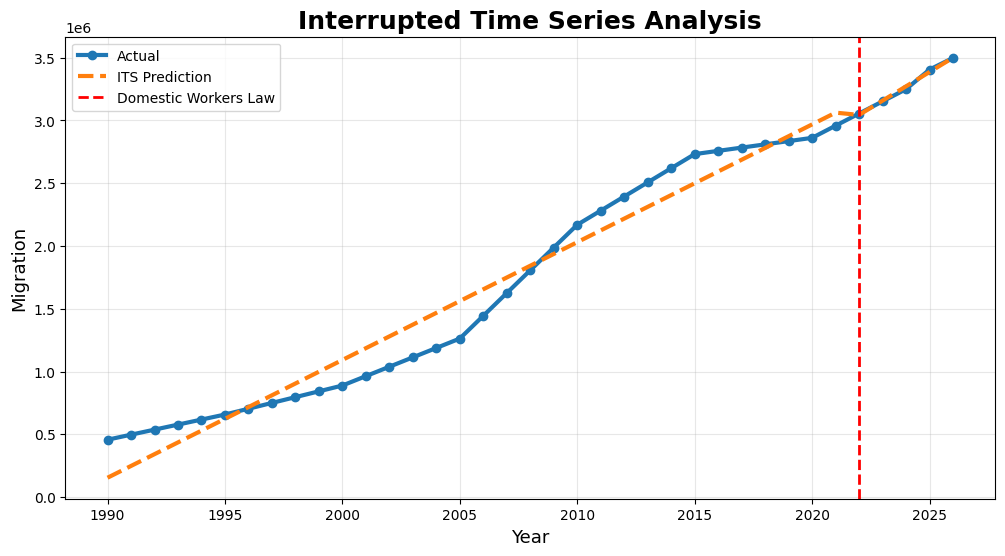

In [ ]:

uae["Prediction"]=its.predict(uae)

plt.figure(figsize=(12,6))

plt.plot(
uae["Year"],
uae["Migration"],
marker="o",
linewidth=3,
label="Actual"
)

plt.plot(
uae["Year"],
uae["Prediction"],
linewidth=3,
linestyle="--",
label="ITS Prediction"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Domestic Workers Law"
)

plt.xlabel("Year",fontsize=13)

plt.ylabel("Migration",fontsize=13)

plt.title(
"Interrupted Time Series Analysis",
fontsize=18,
weight="bold"
)

plt.legend()

plt.grid(alpha=.3)

plt.show()

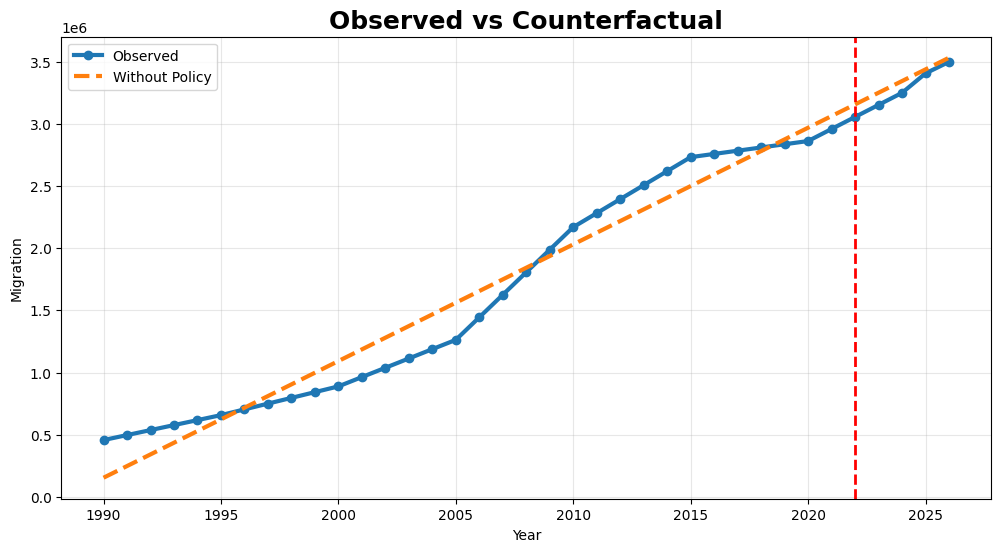

In [ ]:
counter = uae.copy()

counter["Policy"]=0

counter["Time_After"]=0

counter["Counterfactual"]=its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(
uae["Year"],
uae["Migration"],
marker="o",
linewidth=3,
label="Observed"
)

plt.plot(
uae["Year"],
counter["Counterfactual"],
linestyle="--",
linewidth=3,
label="Without Policy"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2
)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title(
"Observed vs Counterfactual",
fontsize=18,
weight="bold"
)

plt.legend()

plt.grid(alpha=.3)

plt.show()

Employment Contract Reform Impact last UAE POLICY $ method 1 descriptive analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# UAE Data
uae = df[df["Country"]=="United Arab Emirates"].copy()

uae = uae.sort_values("Year").reset_index(drop=True)

# Policy Name
policy = "Employment_Contract_Reform"

# Policy Year
policy_year = uae.loc[
    uae[policy]==1,
    "Year"
].min()

print("Policy Year :", policy_year)

# 3 Years Before
before = uae[
    (uae["Year"]>=policy_year-3) &
    (uae["Year"]<policy_year)
]

# All Years After
after = uae[
    uae["Year"]>=policy_year
]

before_avg = before["Migration"].mean()
after_avg = after["Migration"].mean()

increase = after_avg-before_avg

percent=(increase/before_avg)*100

print("Before :",before_avg)
print("After :",after_avg)
print("Increase :",increase)
print("Percentage :",percent)

Policy Year : 2022
Before : 2884706.0
After : 3271537.8
Increase : 386831.7999999998
Percentage : 13.409747821788418


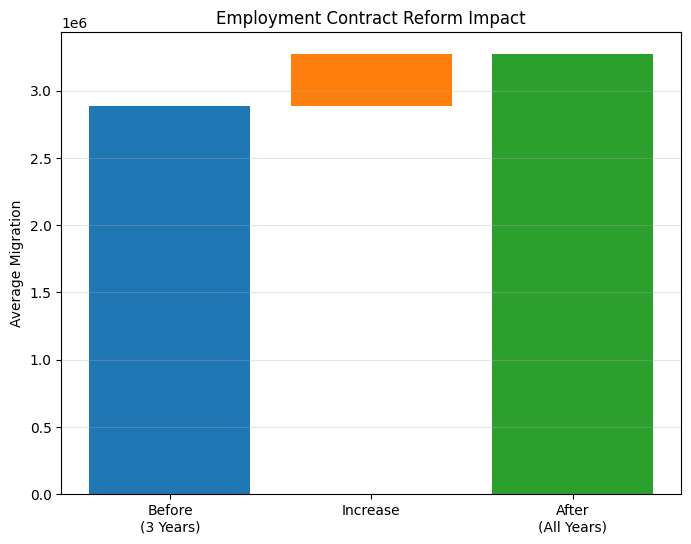

In [ ]:
plt.figure(figsize=(8,6))

plt.bar("Before\n(3 Years)",before_avg)

plt.bar("Increase",increase,bottom=before_avg)

plt.bar("After\n(All Years)",after_avg)

plt.title("Employment Contract Reform Impact")

plt.ylabel("Average Migration")

plt.grid(axis="y",alpha=.3)

plt.show()

Multiple Linear Regression with PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

economic=[
"GDP",
#"Population",
"Inflation",
"Oil_Price",
"Exchange_Rate",
"Unemployment"
]

X=uae[economic]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

PC=pca.fit_transform(X_scaled)

pc_df=pd.DataFrame(
PC,
columns=[f"PC{i+1}" for i in range(PC.shape[1])]
)

data=pd.concat(
[uae.reset_index(drop=True),pc_df],
axis=1
)

In [ ]:
import statsmodels.formula.api as smf

formula="Migration ~ Employment_Contract_Reform"

for col in pc_df.columns:
    formula+=" + "+col

model=smf.ols(
formula,
data=data
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     39.80
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.36e-12
Time:                        05:39:39   Log-Likelihood:                -526.64
No. Observations:                  37   AIC:                             1065.
Df Residuals:                      31   BIC:                             1075.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

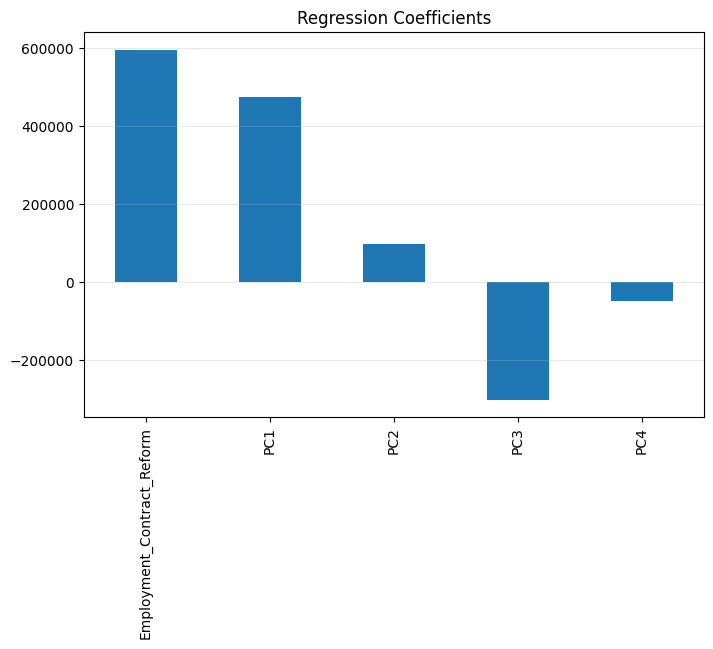

In [ ]:
import matplotlib.pyplot as plt

coef=model.params.drop("Intercept")

plt.figure(figsize=(8,5))

coef.plot(kind="bar")

plt.title("Regression Coefficients")

plt.grid(axis='y',alpha=.3)

plt.show()

Interrupted Time Series

In [ ]:
uae["Time"]=range(1,len(uae)+1)

uae["Policy"]=(uae["Year"]>=policy_year).astype(int)

uae["Time_After"]=uae["Year"]-policy_year+1

uae.loc[
uae["Year"]<policy_year,
"Time_After"
]=0

In [ ]:
its=smf.ols(
"Migration~Time+Policy+Time_After",
data=uae
).fit()

print(its.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     403.4
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           4.58e-26
Time:                        16:09:59   Log-Likelihood:                -496.58
No. Observations:                  37   AIC:                             1001.
Df Residuals:                      33   BIC:                             1008.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.022e+04   6.25e+04      0.963      0.3

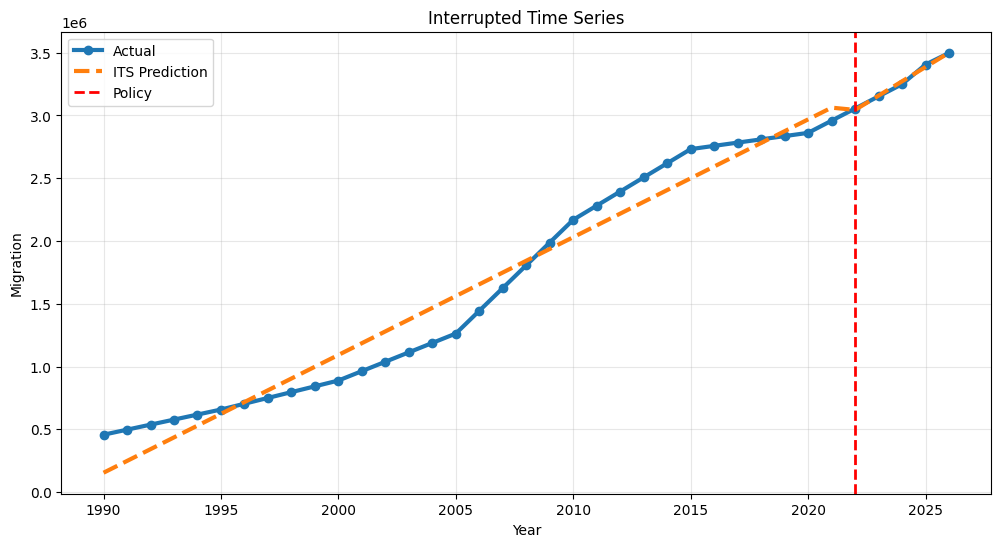

In [ ]:
uae["Prediction"]=its.predict(uae)

plt.figure(figsize=(12,6))

plt.plot(
uae["Year"],
uae["Migration"],
marker='o',
linewidth=3,
label="Actual"
)

plt.plot(
uae["Year"],
uae["Prediction"],
linewidth=3,
linestyle="--",
label="ITS Prediction"
)

plt.axvline(
policy_year,
color="red",
linestyle="--",
linewidth=2,
label="Policy"
)

plt.title("Interrupted Time Series")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.legend()

plt.grid(alpha=.3)

plt.show()